In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df_raw = pd.read_csv("../student_data_categorized.csv")

In [ ]:
# just to look at units only
selected_cols = [col for col in df_raw.columns if 'Curricular units' in col]
df_units = df_raw[selected_cols]

# rename columns so easier to write
rename_dict = {
    'Curricular units 1st sem (credited)': '1st_sem_credited',
    'Curricular units 1st sem (enrolled)': '1st_sem_enrolled',
    'Curricular units 1st sem (evaluations)': '1st_sem_evaluations',
    'Curricular units 1st sem (approved)': '1st_sem_approved',
    'Curricular units 1st sem (grade)': '1st_sem_grade',
    'Curricular units 1st sem (without evaluations)': '1st_sem_without_eval',
    'Curricular units 2nd sem (credited)': '2nd_sem_credited',
    'Curricular units 2nd sem (enrolled)': '2nd_sem_enrolled',
    'Curricular units 2nd sem (evaluations)': '2nd_sem_evaluations',
    'Curricular units 2nd sem (approved)': '2nd_sem_approved',
    'Curricular units 2nd sem (grade)': '2nd_sem_grade',
    'Curricular units 2nd sem (without evaluations)': '2nd_sem_without_eval'
}
df_units = df_units.rename(columns=rename_dict)

df_units.head(5)

,1st_sem_credited,1st_sem_enrolled,1st_sem_evaluations,1st_sem_approved,1st_sem_grade,1st_sem_without_eval,2nd_sem_credited,2nd_sem_enrolled,2nd_sem_evaluations,2nd_sem_approved,2nd_sem_grade,2nd_sem_without_eval
0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0
1,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0
2,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0
3,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0
4,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0


In [20]:
df_units["1st_sem_credited"].unique()

array([ 0,  2,  3,  6,  7, 13,  4,  1,  5, 19, 11,  8, 10,  9, 15, 12, 14,
       18, 17, 16, 20])

In [10]:
# how many students got all 

first_sem = df_units[df_units['1st_sem_credited'] == df_units['1st_sem_enrolled']]
print("fraction of students who got full credit in 1st sem:", len(first_sem), "/", len(df_units))

sec_sem = df_units[df_units['2nd_sem_credited'] == df_units['2nd_sem_enrolled']]
print("fraction of students who got full credit in 2nd sem:", len(sec_sem), "/", len(df_units))
# very few students got full credit

fraction of students who got full credit in 1st sem: 189 / 4424
fraction of students who got full credit in 2nd sem: 194 / 4424


In [19]:
print(len(df_units["1st_sem_credited"] == 0), "/", len(df_units)) 

4244 / 4244


Looks like we can use enrolled, evaluations and compare with approved, credited, grade to compare academic success.

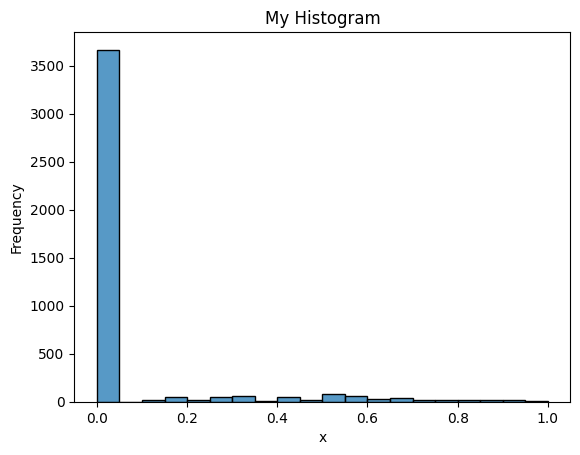

In [16]:
df_units_comp = df_units[df_units['1st_sem_enrolled'] != 0]


df_units_comp["1st_sem_%_credited"] = df_units_comp["1st_sem_credited"]/df_units_comp['1st_sem_enrolled']


sns.histplot(df_units_comp["1st_sem_%_credited"], bins=20)
plt.xlabel("x")
plt.ylabel("Frequency")
plt.title("My Histogram")
plt.show()